# Notebook 04 — Modelo SARIMA para predicción de huella de carbono

Este notebook implementa y evalúa el modelo SARIMA para la predicción
de la huella de carbono eléctrica a horizontes de 48h y 72h.

El orden del modelo se selecciona mediante auto_arima sobre ventanas
representativas de invierno y verano, re-muestreadas a 30 minutos
para reducir el coste computacional.

La evaluación se realiza mediante walk-forward con ventana fija de
historia reciente, dado que el coste computacional de SARIMA con
period=96 hace inviable el uso de ventana expansiva en un entorno local.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

plt.style.use("seaborn-v0_8")
%matplotlib inline

## Carga de datos

In [26]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path.cwd() / "data_processed"

y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"].astype(float)

y_train.index = pd.to_datetime(y_train.index)
y_val.index   = pd.to_datetime(y_val.index)
y_test.index  = pd.to_datetime(y_test.index)

print("Train:", y_train.shape, "|", y_train.index.min(), "->", y_train.index.max())
print("Val:  ", y_val.shape,   "|", y_val.index.min(),   "->", y_val.index.max())
print("Test: ", y_test.shape,  "|", y_test.index.min(),  "->", y_test.index.max())
y_train.head()

Train: (70080,) | 2022-01-01 00:00:00+00:00 -> 2023-12-31 23:45:00+00:00
Val:   (35136,) | 2024-01-01 00:00:00+00:00 -> 2024-12-31 23:45:00+00:00
Test:  (35040,) | 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:45:00+00:00


timestamp
2022-01-01 00:00:00+00:00    120.79
2022-01-01 00:15:00+00:00    120.79
2022-01-01 00:30:00+00:00    120.79
2022-01-01 00:45:00+00:00    120.80
2022-01-01 01:00:00+00:00    120.04
Name: y, dtype: float64

## Configuración temporal y métricas

In [27]:
FREQ_MIN       = 15
STEPS_PER_HOUR = 60 // FREQ_MIN
SEASONAL_PERIOD = 24 * STEPS_PER_HOUR  # 96

HORIZONS = {
    "48h": 48 * STEPS_PER_HOUR,
    "72h": 72 * STEPS_PER_HOUR
}

@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

print("Periodo estacional:", SEASONAL_PERIOD)
print("Horizontes:", HORIZONS)

Periodo estacional: 96
Horizontes: {'48h': 192, '72h': 288}


## Selección SARIMA con ventanas estacionales representativas

Para garantizar que el orden del modelo SARIMA es robusto frente a variaciones
estacionales anuales, se realiza la selección de hiperparámetros utilizando dos
ventanas temporales del conjunto de entrenamiento:

- Un periodo representativo de invierno
- Un periodo representativo de verano

Cada ventana tiene una duración de 14 días, suficiente para capturar múltiples
ciclos diarios completos (s = 96) manteniendo un coste computacional reducido.

Además, se restringieron los órdenes máximos de los parámetros autoregresivos y de media
móvil a valores moderados (p,q ≤ 3 y P,Q ≤ 2) con el objetivo de reducir el coste
computacional y evitar modelos excesivamente complejos.

En series energéticas de alta resolución, órdenes bajos suelen ser suficientes
para capturar dependencias temporales relevantes, especialmente cuando se incluyen
componentes estacionales que incorporan memoria temporal adicional a través del
periodo s.

In [28]:
# Solo para selección de order
# Ventana invierno
winter_sample = y_train.loc["2023-01-01":"2023-01-14"]
summer_sample = y_train.loc["2023-07-01":"2023-07-14"]

y_winter_30m = winter_sample.resample("30min").mean().dropna()
y_summer_30m = summer_sample.resample("30min").mean().dropna()

print("Winter 30m:", len(y_winter_30m), "obs")
print("Summer 30m:", len(y_summer_30m), "obs")

def auto_sarima_fast(series, m):
    return pm.auto_arima(
        series.values,
        seasonal=True, m=m,
        start_p=0, start_q=0, max_p=2, max_q=2,
        start_P=0, start_Q=0, max_P=1, max_Q=1,
        d=None, D=1,
        stepwise=True,
        max_order=6,
        information_criterion="aic",
        suppress_warnings=True,
        error_action="ignore",
        trace=True
    )

auto_w = auto_sarima_fast(y_winter_30m, m=48)
auto_s = auto_sarima_fast(y_summer_30m, m=48)

print("\nWinter:", auto_w.order, auto_w.seasonal_order)
print("Summer:", auto_s.order, auto_s.seasonal_order)

Winter 30m: 672 obs
Summer 30m: 672 obs
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[48]             : AIC=3646.470, Time=0.45 sec
 ARIMA(1,1,0)(1,1,0)[48]             : AIC=3500.202, Time=1.58 sec
 ARIMA(0,1,1)(0,1,1)[48]             : AIC=inf, Time=10.07 sec
 ARIMA(1,1,0)(0,1,0)[48]             : AIC=3586.896, Time=0.25 sec
 ARIMA(1,1,0)(1,1,1)[48]             : AIC=inf, Time=18.11 sec
 ARIMA(1,1,0)(0,1,1)[48]             : AIC=inf, Time=13.96 sec
 ARIMA(0,1,0)(1,1,0)[48]             : AIC=3595.935, Time=1.14 sec
 ARIMA(2,1,0)(1,1,0)[48]             : AIC=3497.762, Time=2.20 sec
 ARIMA(2,1,0)(0,1,0)[48]             : AIC=3584.965, Time=0.38 sec
 ARIMA(2,1,0)(1,1,1)[48]             : AIC=inf, Time=26.19 sec
 ARIMA(2,1,0)(0,1,1)[48]             : AIC=inf, Time=14.89 sec
 ARIMA(2,1,1)(1,1,0)[48]             : AIC=3498.959, Time=4.34 sec
 ARIMA(1,1,1)(1,1,0)[48]             : AIC=3498.615, Time=2.22 sec
 ARIMA(2,1,0)(1,1,0)[48] intercept   : AIC=3499.742, Time=6.46 sec

Para reducir el coste computacional en la selección de SARIMA, se re-muestrea la serie
a 30 minutos exclusivamente en la fase de identificación del orden. Esto preserva la
estacionalidad diaria y la estructura de autocorrelación relevante, mientras reduce el
número de observaciones y acelera el ajuste. La evaluación final se realiza en la
resolución original de 15 minutos.

## Modelo SARIMA final (resolución 15 min)

La selección de hiperparámetros se realizó mediante criterios de información
(AIC) en ventanas de invierno y verano re-muestreadas a 30 minutos
(m = 48), obteniendo en ambos casos el mismo orden SARIMA(2,1,0)(1,1,0)\_{48}. Esta coincidencia sugiere
estabilidad estacional del orden del modelo.

Para la evaluación final en la resolución original de 15 minutos, se mantiene el mismo orden y se ajusta
el periodo estacional a m = 96 (24h).

In [29]:
sarima_order          = (2, 1, 0)
sarima_seasonal_order = (1, 1, 0, 96)

print("SARIMA final:", sarima_order, sarima_seasonal_order)

SARIMA final: (2, 1, 0) (1, 1, 0, 96)


## Función de forecasting SARIMA

In [30]:
def forecast_sarima(train, h, order, seasonal_order, maxiter=20):
    model = SARIMAX(
        train.values,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False, maxiter=maxiter, method="lbfgs")
    return res.forecast(steps=h)

## Evaluación walk-forward

Se usa ventana fija de historia reciente (train_window_days=14)
y re-entrenamiento cada 28 días con un máximo de 10 fits.

Esta configuración reducida es una limitación conocida del trabajo
debida al coste computacional de SARIMA con period=96 en un entorno
local. Se documenta explícitamente para su consideración en la
interpretación de resultados.

In [31]:
def walk_forward_splits(series, horizons, cfg):
    n     = len(series)
    max_h = max(horizons.values())
    points = list(range(cfg.min_history, n - max_h, cfg.step))
    points = points[:cfg.max_fits]
    for t0 in points:
        train_part = series.iloc[:t0]
        tests = {k: series.iloc[t0:t0 + h] for k, h in horizons.items()}
        yield train_part, tests

def evaluate_sarima(y_train, y_val, horizons, cfg,
                    order, seasonal_order,
                    train_window_days=21, verbose=True):
    rows  = []
    # Concatenar train+val completos para tener contexto continuo
    y_full = pd.concat([y_train, y_val]).sort_index()
    n_train = len(y_train)
    
    splits = list(walk_forward_splits(y_val, horizons, cfg))
    total  = len(splits)

    for i, (train_part, tests) in enumerate(splits, 1):
        if verbose:
            print(f"Fit {i}/{total}")

        # Punto de corte en la serie completa
        cutoff_idx = n_train + len(train_part)
        cutoff_time = y_full.index[cutoff_idx - 1]
        window_start = cutoff_time - pd.Timedelta(days=train_window_days)
        
        # Ventana de historia continua desde train+val
        train_window = y_full.loc[
            (y_full.index > window_start) & 
            (y_full.index <= cutoff_time)
        ]

        for name, test in tests.items():
            pred = forecast_sarima(train_window, len(test), order, seasonal_order)
            m    = compute_metrics(test.values, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})


    return pd.DataFrame(rows)

## Configuración del walk-forward y ejecución

In [32]:
cfg_sarima = WFConfig(
    step=28 * SEASONAL_PERIOD,
    min_history=21 * SEASONAL_PERIOD,
    max_fits=10
)

sarima_val = evaluate_sarima(
    y_train, y_val,
    HORIZONS, cfg_sarima,
    sarima_order, sarima_seasonal_order,
    train_window_days=30
)

print("Filas generadas:", len(sarima_val))
sarima_val.head()

Fit 1/10
Fit 2/10
Fit 3/10
Fit 4/10
Fit 5/10
Fit 6/10
Fit 7/10
Fit 8/10
Fit 9/10
Fit 10/10
Filas generadas: 20


,horizon,MAE,RMSE
0,48h,16.718047,21.942620
1,72h,19.191783,23.348835
2,48h,20.136583,24.820891
3,72h,26.178863,30.749286
4,48h,11.149661,15.117068


## Resultados

In [33]:
def summarize(df, model_name):
    out = (
        df.groupby("horizon")[["MAE", "RMSE"]]
        .mean()
        .reset_index()
    )
    out.insert(0, "model", model_name)
    return out

sarima_summary = summarize(sarima_val, "SARIMA(2,1,0)(1,1,0,96)")

# Guardar resultados
RESULTS_DIR = Path.cwd().parent / "results"
RESULTS_DIR.mkdir(exist_ok=True)
sarima_summary.to_csv(RESULTS_DIR / "sarima_summary.csv", index=False)
print(sarima_summary)



                     model horizon        MAE       RMSE
0  SARIMA(2,1,0)(1,1,0,96)     48h  18.911210  23.120290
1  SARIMA(2,1,0)(1,1,0,96)     72h  23.795698  28.988228


In [34]:
# Cargar y comparar todos los modelos
naive_summary = pd.read_csv(RESULTS_DIR / "naive_summary.csv")
arima_summary = pd.read_csv(RESULTS_DIR / "arima_summary.csv")

compare_val = pd.concat([
    naive_summary,
    arima_summary,
    sarima_summary
], ignore_index=True)

compare_val

,model,horizon,MAE,RMSE
0,Naive_last,48h,20.174324,24.491983
1,Naive_last,72h,21.887282,26.416587
2,Naive_seasonal,48h,16.510456,20.179678
3,Naive_seasonal,72h,17.744089,21.888852
4,"ARIMA(5, 1, 0)",48h,20.414305,24.609350
5,"ARIMA(5, 1, 0)",72h,21.911410,26.260707
6,"SARIMA(2,1,0)(1,1,0,96)",48h,18.911210,23.120290
7,"SARIMA(2,1,0)(1,1,0,96)",72h,23.795698,28.988228


In [35]:
naive_summary = pd.read_csv(RESULTS_DIR / "naive_summary.csv")
arima_summary = pd.read_csv(RESULTS_DIR / "arima_summary.csv")

compare_val = pd.concat([
    naive_summary,
    arima_summary,
    sarima_summary
], ignore_index=True)

compare_val

,model,horizon,MAE,RMSE
0,Naive_last,48h,20.174324,24.491983
1,Naive_last,72h,21.887282,26.416587
2,Naive_seasonal,48h,16.510456,20.179678
3,Naive_seasonal,72h,17.744089,21.888852
4,"ARIMA(5, 1, 0)",48h,20.414305,24.609350
5,"ARIMA(5, 1, 0)",72h,21.911410,26.260707
6,"SARIMA(2,1,0)(1,1,0,96)",48h,18.911210,23.120290
7,"SARIMA(2,1,0)(1,1,0,96)",72h,23.795698,28.988228


In [36]:
naive_summary = pd.read_csv(RESULTS_DIR / "naive_summary.csv")
arima_summary = pd.read_csv(RESULTS_DIR / "arima_summary.csv")

compare_val = pd.concat([
    naive_summary,
    arima_summary,
    sarima_summary
], ignore_index=True)

def pretty_print(summary):
    for model in summary["model"].unique():
        sub = summary[summary["model"] == model]
        print("\n", model)
        for _, r in sub.iterrows():
            print(
                f"{r['horizon']} -> "
                f"MAE: {r['MAE']:.3f} | "
                f"RMSE: {r['RMSE']:.3f}"
            )

pretty_print(compare_val)


 Naive_last
48h -> MAE: 20.174 | RMSE: 24.492
72h -> MAE: 21.887 | RMSE: 26.417

 Naive_seasonal
48h -> MAE: 16.510 | RMSE: 20.180
72h -> MAE: 17.744 | RMSE: 21.889

 ARIMA(5, 1, 0)
48h -> MAE: 20.414 | RMSE: 24.609
72h -> MAE: 21.911 | RMSE: 26.261

 SARIMA(2,1,0)(1,1,0,96)
48h -> MAE: 18.911 | RMSE: 23.120
72h -> MAE: 23.796 | RMSE: 28.988


## Visualización de predicciones SARIMA vs valores reales

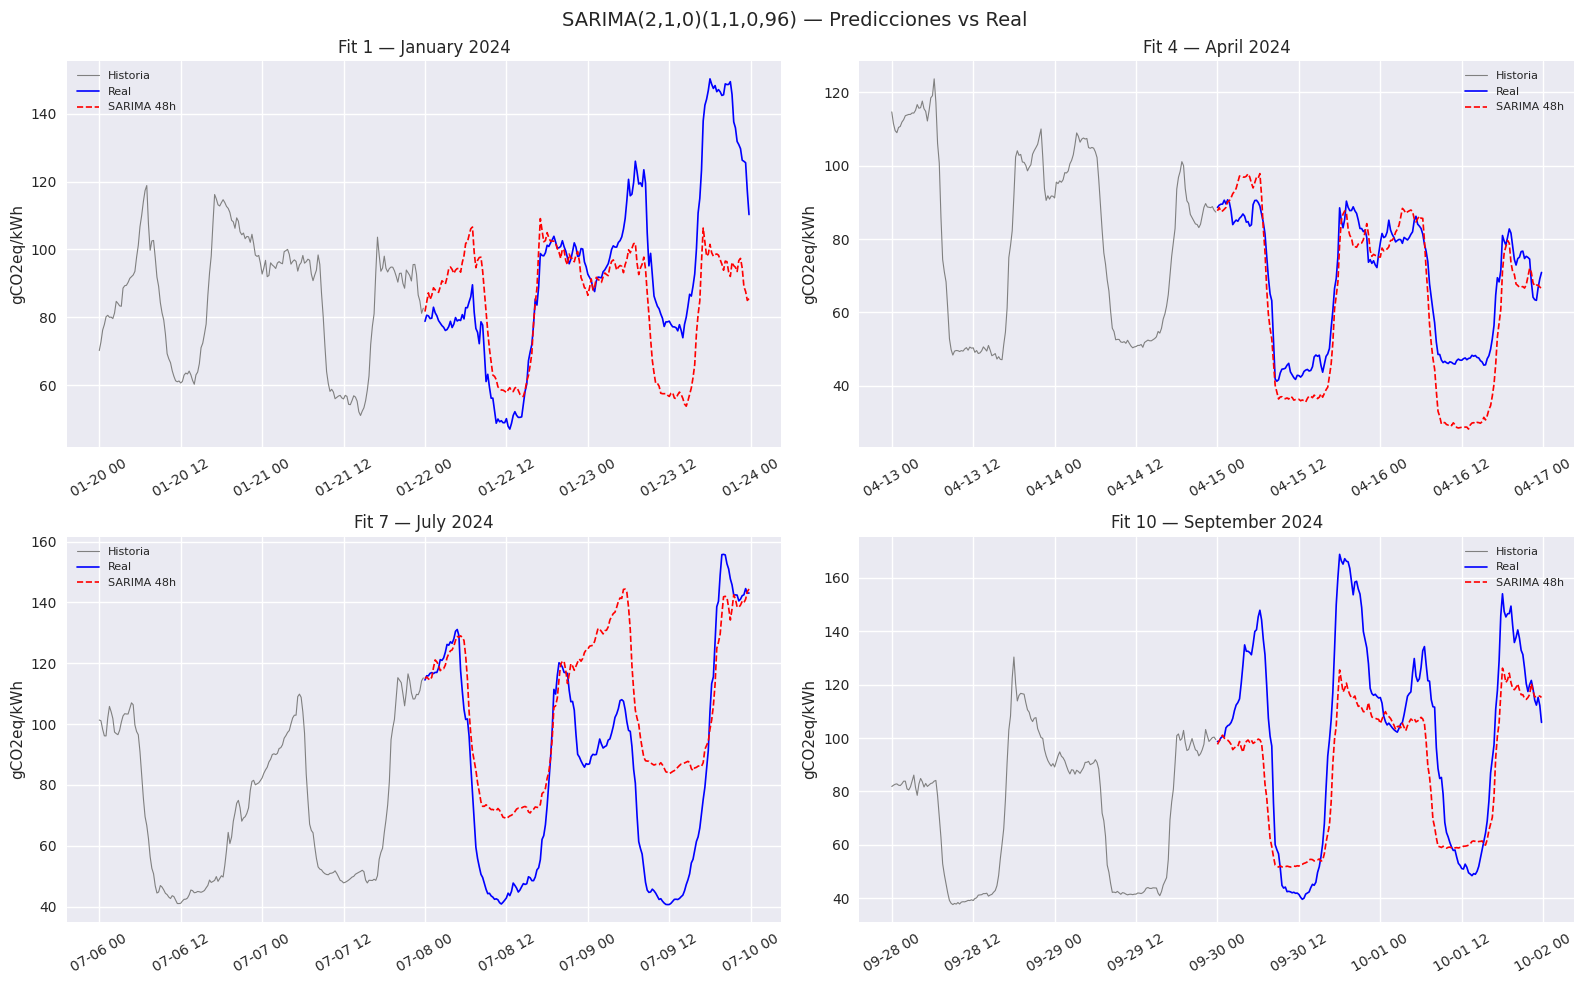

Guardado en figures/sarima_predicciones.png


In [37]:
import matplotlib.pyplot as plt

# Cogemos el primer split para visualizar
y_full = pd.concat([y_train, y_val]).sort_index()
splits = list(walk_forward_splits(y_val, HORIZONS, cfg_sarima))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("SARIMA(2,1,0)(1,1,0,96) — Predicciones vs Real", fontsize=14)

for idx, split_idx in enumerate([0, 3, 6, 9]):
    ax = axes[idx // 2][idx % 2]
    
    train_part, tests = splits[split_idx]
    
    # Reconstruir ventana de entrenamiento
    cutoff_idx  = len(y_train) + len(train_part)
    cutoff_time = y_full.index[cutoff_idx - 1]
    window_start = cutoff_time - pd.Timedelta(days=30)
    train_window = y_full.loc[
        (y_full.index > window_start) &
        (y_full.index <= cutoff_time)
    ]
    
    # Predicción 48h
    test_48 = tests["48h"]
    pred_48 = forecast_sarima(train_window, len(test_48),
                               sarima_order, sarima_seasonal_order)
    
    # Plot últimos 2 días de historia + predicción + real
    history = train_window.iloc[-192:]
    ax.plot(history.index, history.values,
            color="gray", label="Historia", linewidth=0.8)
    ax.plot(test_48.index, test_48.values,
            color="blue", label="Real", linewidth=1.2)
    ax.plot(test_48.index, pred_48,
            color="red", linestyle="--", label="SARIMA 48h", linewidth=1.2)
    
    ax.set_title(f"Fit {split_idx + 1} — {cutoff_time.strftime('%B %Y')}")
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../figures/sarima_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado en figures/sarima_predicciones.png")

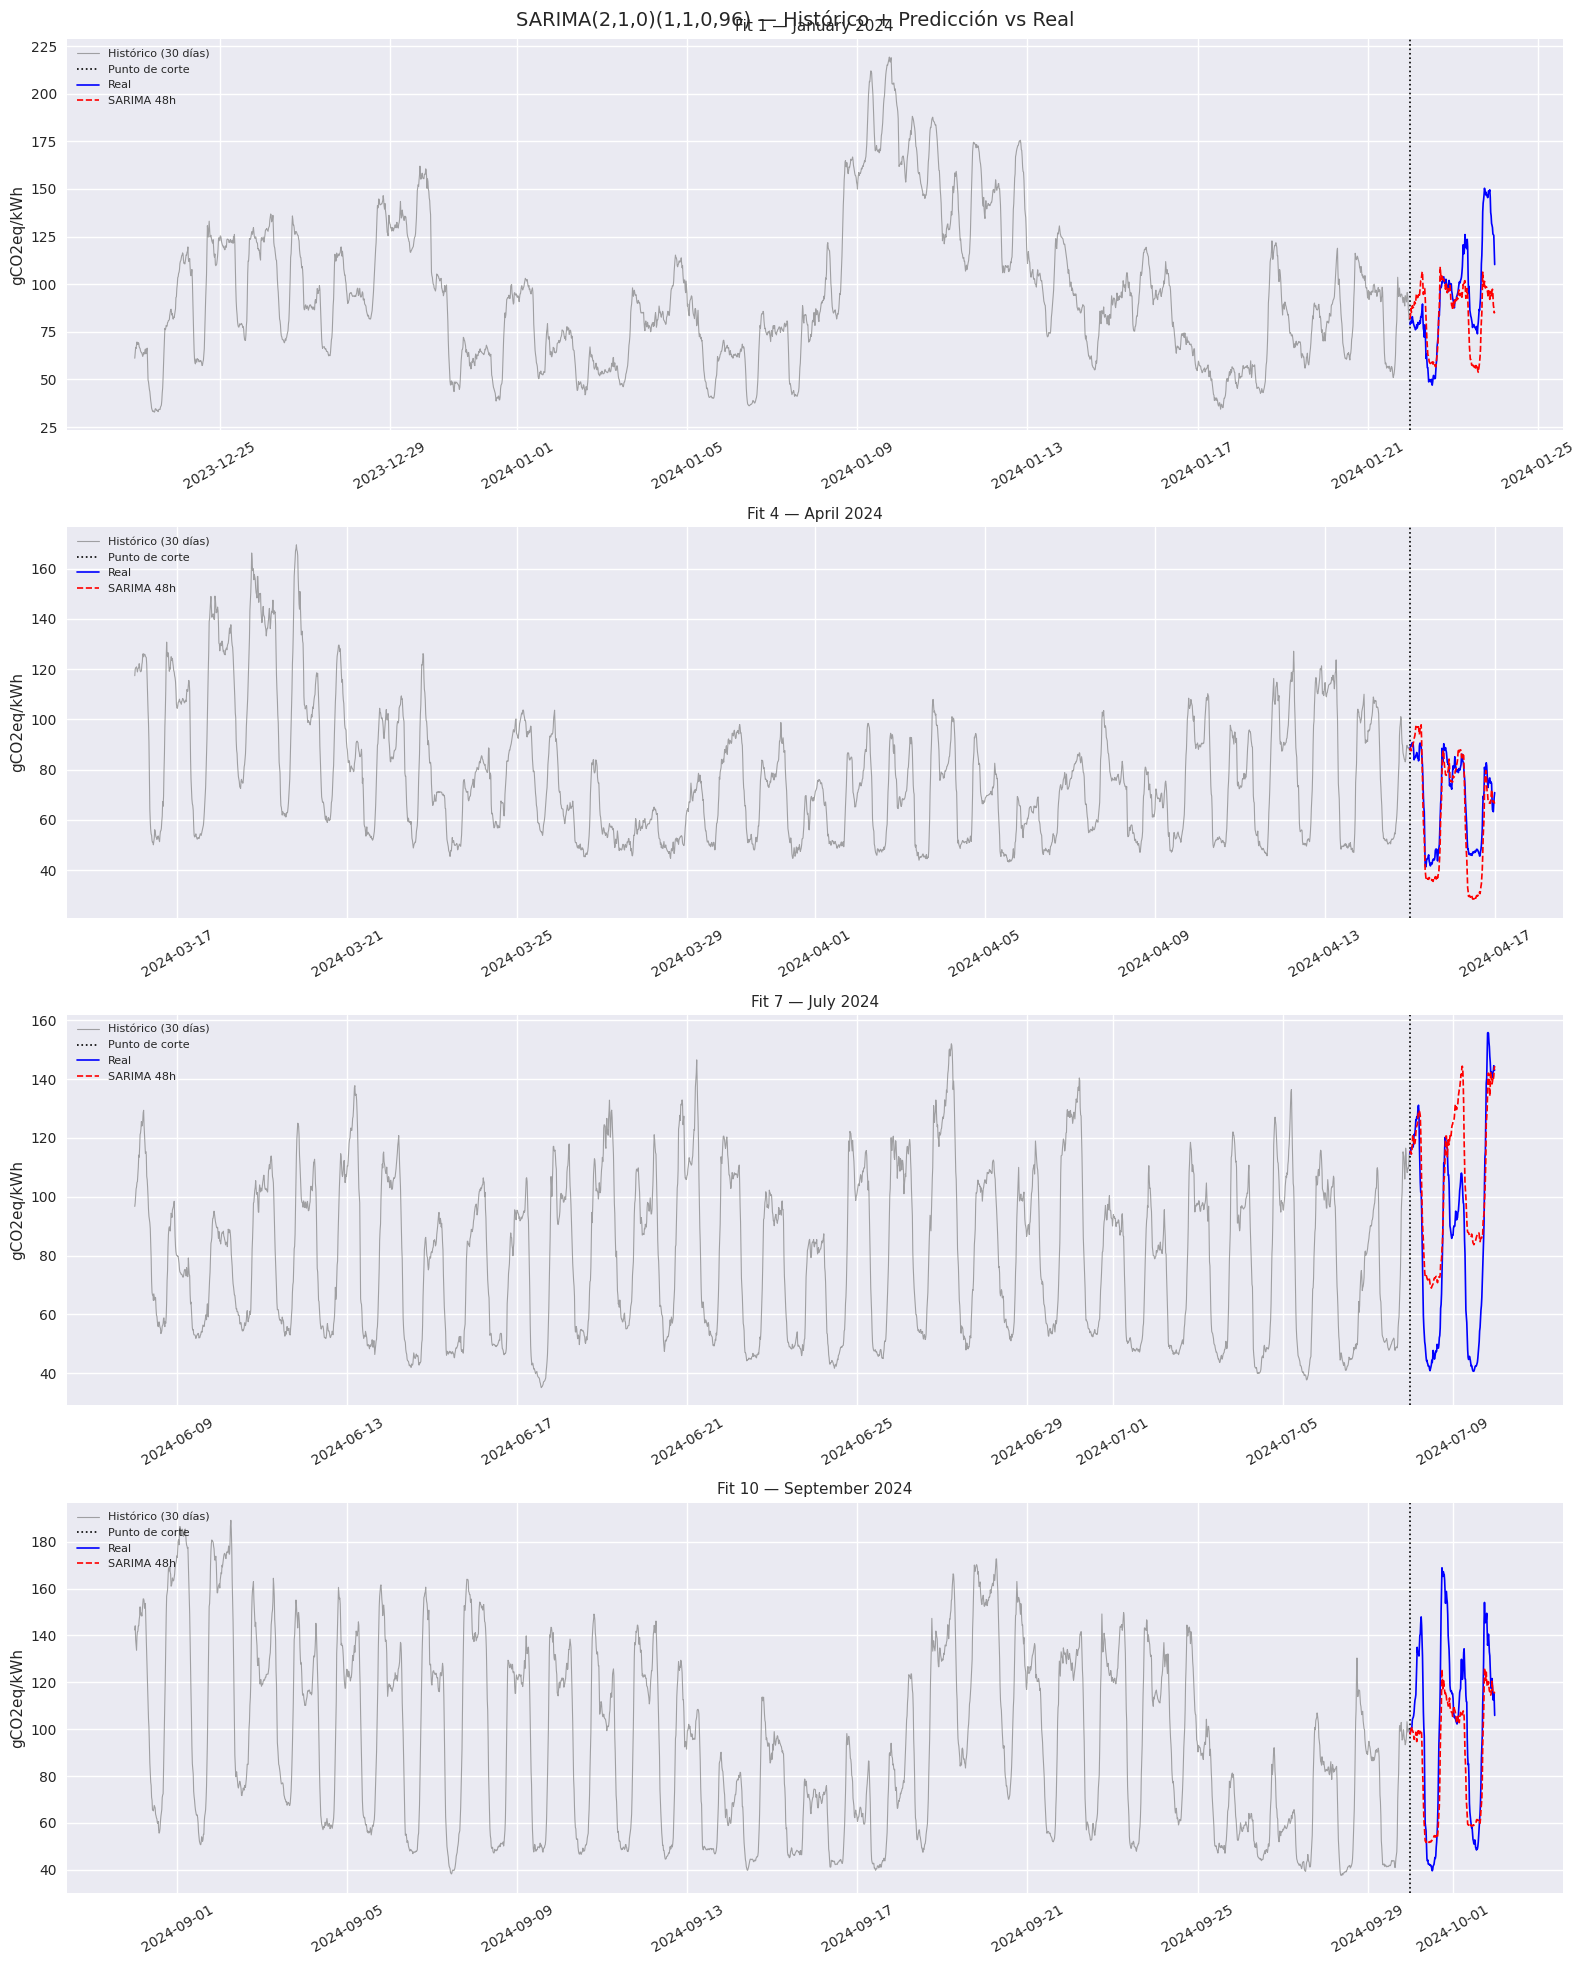

In [38]:
fig, axes = plt.subplots(4, 1, figsize=(16, 20))
fig.suptitle("SARIMA(2,1,0)(1,1,0,96) — Histórico + Predicción vs Real", fontsize=14)

splits = list(walk_forward_splits(y_val, HORIZONS, cfg_sarima))

for idx, split_idx in enumerate([0, 3, 6, 9]):
    ax = axes[idx]
    
    train_part, tests = splits[split_idx]
    
    # Reconstruir ventana
    cutoff_idx   = len(y_train) + len(train_part)
    cutoff_time  = y_full.index[cutoff_idx - 1]
    window_start = cutoff_time - pd.Timedelta(days=30)
    train_window = y_full.loc[
        (y_full.index > window_start) &
        (y_full.index <= cutoff_time)
    ]
    
    # Predicción 48h
    test_48 = tests["48h"]
    pred_48 = forecast_sarima(train_window, len(test_48),
                               sarima_order, sarima_seasonal_order)
    pred_index = test_48.index

    # Plot histórico completo (30 días)
    ax.plot(train_window.index, train_window.values,
            color="gray", label="Histórico (30 días)", linewidth=0.8, alpha=0.7)
    
    # Línea vertical en punto de corte
    ax.axvline(x=cutoff_time, color="black", linestyle=":", linewidth=1.2, label="Punto de corte")
    
    # Real vs predicho
    ax.plot(pred_index, test_48.values,
            color="blue", label="Real", linewidth=1.2)
    ax.plot(pred_index, pred_48,
            color="red", linestyle="--", label="SARIMA 48h", linewidth=1.2)
    
    ax.set_title(f"Fit {split_idx + 1} — {cutoff_time.strftime('%B %Y')}", fontsize=11)
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8, loc="upper left")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../figures/sarima_historico_prediccion.png", dpi=150, bbox_inches="tight")
plt.show()